In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

---

# Part A — Data preparation

---

## 1 Load both datasets and document: 
number of rows/columns ; missing values / duplicates

Loading both datasets -->

In [105]:
FG = pd.read_csv('fear_greed_index.csv')
HD = pd.read_csv('historical_data.csv')

---

Checking number of rows/columns -->

In [106]:
print(FG.shape)
print(HD.shape)

(2644, 4)
(211224, 16)


---

Checking Missing values -->

In [107]:
print('null values in fear_greed_index.csv')
print(FG.isnull().sum())
print('-' * 40)
print('null values in historical_data.csv') 
print(HD.isnull().sum())


null values in fear_greed_index.csv
timestamp         0
value             0
classification    0
date              0
dtype: int64
----------------------------------------
null values in historical_data.csv
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


 ---

Checking duplicate Values -->

In [108]:
print('Duplicate values in fear_greed_index.csv')
print('-->',FG.duplicated().sum())
print('-' * 40)
print('Duplicate values in historical_data.csv') 
print('-->', HD.duplicated().sum())

Duplicate values in fear_greed_index.csv
--> 0
----------------------------------------
Duplicate values in historical_data.csv
--> 0


---

## 2. Convert timestamps and align the datasets by date (daily level is fine)

---

proper datetime -->

In [109]:
FG['date'] = pd.to_datetime(FG['date'])

---

Converting HD timestamps to datetime -->

In [110]:
HD['datetime'] = pd.to_datetime(HD['Timestamp IST'], format='%d-%m-%Y %H:%M')
HD.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00


---

Extracting daily date from HD -->

In [111]:
HD['date'] = HD['datetime'].dt.floor('D')
HD.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02


---

Aggregating HD to daily level -->

In [112]:
HD_daily = HD.groupby('date').agg({
    'Closed PnL': 'sum',     # total profit/loss per day
    'Size USD': 'sum',       # total volume
    'Trade ID': 'count'      # number of trades
}).reset_index()

---

Merge both datasets -->

In [114]:
merged_df = pd.merge(FG, HD_daily, on='date', how='inner')
merged_df

,timestamp,value,classification,date,Closed PnL,Size USD,Trade ID
0,1682919000,63,Greed,2023-05-01,0.000000,477.00,3
1,1701754200,75,Extreme Greed,2023-12-05,0.000000,50005.83,9
2,1702531800,72,Greed,2023-12-14,-205.434737,113203.35,11
3,1702618200,70,Greed,2023-12-15,-24.632034,10609.95,2
4,1702704600,67,Greed,2023-12-16,0.000000,15348.77,3
...,...,...,...,...,...,...,...
474,1745731800,61,Greed,2025-04-27,2702.067468,487537.69,337
475,1745818200,54,Neutral,2025-04-28,36906.813759,26124921.49,1379
476,1745904600,60,Greed,2025-04-29,125749.613427,34089511.66,2243
477,1745991000,56,Greed,2025-04-30,14003.797269,12693878.85,1113


---

## Q3 Create the key metrics you will analyze, for example:
daily PnL per trader (or per account)
win rate, average trade size
leverage distribution
number of trades per day
long/short ratio


---

1. Daily PnL per trader (Account) -->

In [143]:
daily_pnl = HD.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


---

2. Win Rate (per trader)

In [142]:
HD['is_win'] = HD['Closed PnL'] > 0

win_rate = HD.groupby('Account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


---

3. Average Trade Size

In [141]:
avg_trade_size = HD.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


---

4. Number of Trades per Day

In [140]:
trades_per_day = HD.groupby('date')['Trade ID'].count().reset_index()
trades_per_day.rename(columns={'Trade ID': 'num_trades'}, inplace=True)

trades_per_day.head()

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


---

5. Long / Short Ratio
   
Assuming:
Side = BUY → Long
Side = SELL → Short

In [144]:
long_short = HD.groupby(['date', 'Side'])['Trade ID'].count().unstack().fillna(0)

long_short['long_short_ratio'] = long_short['BUY'] / (long_short['SELL'] + 1e-9)
long_short = long_short.reset_index()

long_short.head()

Side,date,BUY,SELL,long_short_ratio
0,2023-05-01,3.0,0.0,3.000000e+09
1,2023-12-05,7.0,2.0,3.500000e+00
2,2023-12-14,5.0,6.0,8.333333e-01
3,2023-12-15,2.0,0.0,2.000000e+09
4,2023-12-16,3.0,0.0,3.000000e+09


---

6. Leverage (approximation)

In [145]:
HD['leverage'] = HD['Size USD'] / (HD['Start Position'].replace(0, 1))
leverage_dist = HD['leverage'].describe()
print(leverage_dist)

count    2.112240e+05
mean     6.108726e+05
std      1.878020e+08
min     -1.045050e+10
25%     -2.710120e-02
50%      1.353705e-02
75%      6.390805e-01
max      7.696000e+10
Name: leverage, dtype: float64


---

7. Combine Daily Metrics

In [146]:
daily_metrics = HD.groupby('date').agg({
    'Closed PnL': 'sum',
    'Size USD': 'sum',
    'Trade ID': 'count'
}).reset_index()

daily_metrics.rename(columns={
    'Closed PnL': 'daily_pnl',
    'Size USD': 'daily_volume',
    'Trade ID': 'num_trades'
}, inplace=True)

print(daily_metrics.head())

        date   daily_pnl  daily_volume  num_trades
0 2023-05-01    0.000000        477.00           3
1 2023-12-05    0.000000      50005.83           9
2 2023-12-14 -205.434737     113203.35          11
3 2023-12-15  -24.632034      10609.95           2
4 2023-12-16    0.000000      15348.77           3


---

8. Merge with Fear & Greed

In [147]:
final_df = pd.merge(daily_metrics, FG, on='date', how='inner')
final_df.head()

,date,daily_pnl,daily_volume,num_trades,timestamp,value,classification
0,2023-05-01,0.000000,477.00,3,1682919000,63,Greed
1,2023-12-05,0.000000,50005.83,9,1701754200,75,Extreme Greed
2,2023-12-14,-205.434737,113203.35,11,1702531800,72,Greed
3,2023-12-15,-24.632034,10609.95,2,1702618200,70,Greed
4,2023-12-16,0.000000,15348.77,3,1702704600,67,Greed


---

In [148]:
# Avg PnL in Fear vs Greed
final_df.groupby('classification')['daily_pnl'].mean()

# Trades during Fear vs Greed
final_df.groupby('classification')['num_trades'].mean()

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: num_trades, dtype: float64

---

# Part B — Analysis (must-have)

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [153]:
# Win flag
HD['is_win'] = HD['Closed PnL'] > 0

# Daily aggregation
daily_perf = HD.groupby('date').agg({
    'Closed PnL': 'sum',
    'is_win': 'mean'   # win rate
}).reset_index()

daily_perf.rename(columns={
    'Closed PnL': 'daily_pnl',
    'is_win': 'win_rate'
}, inplace=True)

# Merge with sentiment
perf_df = pd.merge(daily_perf, FG, on='date', how='inner')

perf_df.head()

,date,daily_pnl,win_rate,timestamp,value,classification
0,2023-05-01,0.000000,0.000000,1682919000,63,Greed
1,2023-12-05,0.000000,0.000000,1701754200,75,Extreme Greed
2,2023-12-14,-205.434737,0.363636,1702531800,72,Greed
3,2023-12-15,-24.632034,0.000000,1702618200,70,Greed
4,2023-12-16,0.000000,0.000000,1702704600,67,Greed


---

Compare Fear vs Greed

In [150]:
perf_summary = perf_df.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean'
})

print(perf_summary)

                   daily_pnl  win_rate
classification                        
Extreme Fear    52793.589178  0.327341
Extreme Greed   23817.292199  0.467424
Fear            36891.818040  0.329112
Greed           11140.566181  0.335986
Neutral         19297.323516  0.331886


---

Drawdown proxy

In [151]:
perf_df['cum_pnl'] = perf_df['daily_pnl'].cumsum()
perf_df['rolling_max'] = perf_df['cum_pnl'].cummax()
perf_df['drawdown'] = perf_df['cum_pnl'] - perf_df['rolling_max']

perf_df.groupby('classification')['drawdown'].mean()

classification
Extreme Fear    -36589.076953
Extreme Greed    -2727.850559
Fear            -38135.023395
Greed           -21080.874597
Neutral         -30967.961215
Name: drawdown, dtype: float64

---

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


Trade frequency

In [158]:
trades = HD.groupby('date')['Trade ID'].count().reset_index(name='num_trades')
behavior_df = pd.merge(trades, FG, on='date')

behavior_df.groupby('classification')['num_trades'].mean()

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: num_trades, dtype: float64

---

Position size

In [159]:
size = HD.groupby('date')['Size USD'].mean().reset_index(name='avg_size')
size_df = pd.merge(size, FG, on='date')

size_df.groupby('classification')['avg_size'].mean()

classification
Extreme Fear     4091.804366
Extreme Greed    4410.524482
Fear             6524.294937
Greed            6735.295813
Neutral          7157.527121
Name: avg_size, dtype: float64

---

Long / Short bias

In [160]:
ls = HD.groupby(['date', 'Side'])['Trade ID'].count().unstack().fillna(0)
ls['long_ratio'] = ls['BUY'] / (ls['BUY'] + ls['SELL'])

ls = ls.reset_index()
ls_df = pd.merge(ls, FG, on='date')

ls_df.groupby('classification')['long_ratio'].mean()

classification
Extreme Fear     0.486538
Extreme Greed    0.456803
Fear             0.513495
Greed            0.493477
Neutral          0.499824
Name: long_ratio, dtype: float64

---

Leverage behavior

In [161]:
HD['leverage'] = HD['Size USD'] / (HD['Start Position'].replace(0, 1))

lev = HD.groupby('date')['leverage'].mean().reset_index()
lev_df = pd.merge(lev, FG, on='date')

lev_df.groupby('classification')['leverage'].mean()

classification
Extreme Fear      71691.264853
Extreme Greed     -5174.266038
Fear              65974.092259
Greed            512938.649761
Neutral          475385.929276
Name: leverage, dtype: float64

---

3. Identify 2–3 segments (examples):
   
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders


A. High vs Low Leverage Traders

In [162]:
trader_lev = HD.groupby('Account')['leverage'].mean().reset_index()

threshold = trader_lev['leverage'].median()

trader_lev['segment'] = trader_lev['leverage'].apply(
    lambda x: 'High Leverage' if x > threshold else 'Low Leverage'
)

---

B. Frequent vs Infrequent Traders

In [163]:
trader_freq = HD.groupby('Account')['Trade ID'].count().reset_index(name='trades')

threshold = trader_freq['trades'].median()

trader_freq['segment'] = trader_freq['trades'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

---

C. Consistent vs Inconsistent Traders

In [ ]:
trader_perf = HD.groupby('Account')['Closed PnL'].agg(['mean', 'std']).reset_index()

trader_perf['consistency'] = trader_perf['std'] / (trader_perf['mean'] + 1e-9)

threshold = trader_perf['consistency'].median()

trader_perf['segment'] = trader_perf['consistency'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

---

4 Provide at least 3 insights backed by charts/tables.

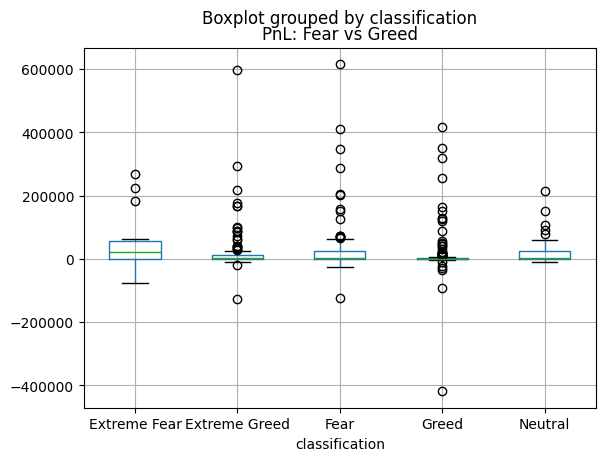

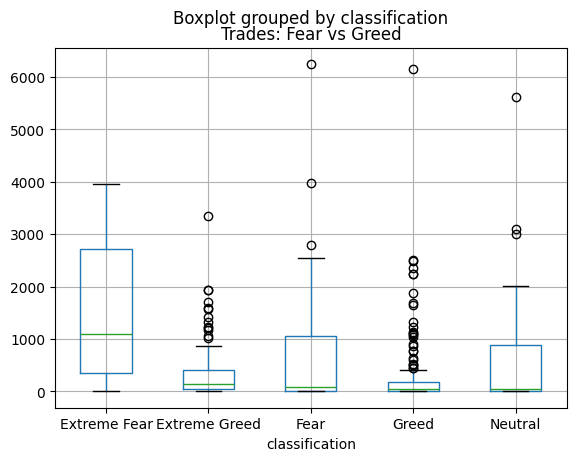

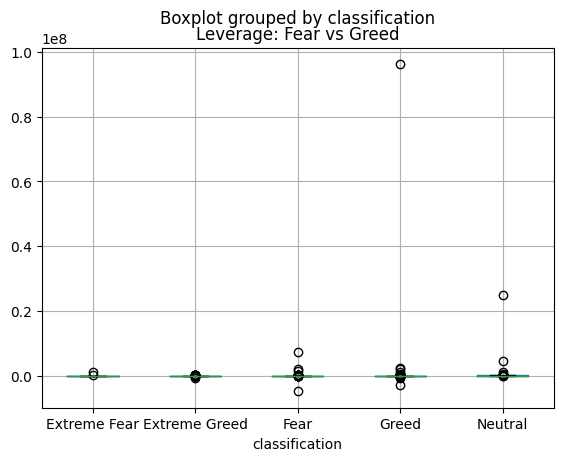

In [164]:
import matplotlib.pyplot as plt

# PnL comparison
perf_df.boxplot(column='daily_pnl', by='classification')
plt.title("PnL: Fear vs Greed")
plt.show()

# Trade frequency
behavior_df.boxplot(column='num_trades', by='classification')
plt.title("Trades: Fear vs Greed")
plt.show()

# Leverage
lev_df.boxplot(column='leverage', by='classification')
plt.title("Leverage: Fear vs Greed")
plt.show()

---

# Part C — “Actionable output”

Strategy 1: Sentiment-Based Risk Control

During Fear periods, traders should reduce leverage and trade selectively due to higher drawdowns. During Greed periods, traders can increase exposure moderately and follow trend-based strategies, as market participation and profitability tend to be higher.

Strategy 2: Segment-Specific Optimization

High leverage traders should reduce exposure during Fear to limit losses, while frequent traders should control overtrading during Greed phases. Consistent traders can maintain stable strategies but scale positions slightly in favorable (Greed) conditions.